In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pgmpy==0.1.23 --quiet
!pip install numpy==1.23.5 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 983.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 61.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curr

In [ ]:
# Restart the runtime to apply changes
import os
os.kill(os.getpid(), 9)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from pgmpy.models import BayesianModel
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

from sklearn.model_selection import train_test_split

In [6]:
path = '/content/drive/MyDrive/2024_2025/PSM_2024_2025/Bayes_Fuzzy_Final/weatherAUS.csv'

data = pd.read_csv(path, delimiter=';')

# Step 3: Select and prepare relevant columns
features = ['WindGustSpeed', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'RainTomorrow']
df = data[features].dropna().copy()
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Step 4: Discretize continuous features into 3 categories
binning = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df[['WindGustSpeed', 'Humidity9am', 'Humidity3pm', 'Pressure9am']] = binning.fit_transform(
    df[['WindGustSpeed', 'Humidity9am', 'Humidity3pm', 'Pressure9am']]
)
df = df.astype(int)

# Step 5: Split the data into train and test sets
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Combine X and y back into DataFrames for training and testing
train_data = X_train.copy()
train_data['RainTomorrow'] = y_train

test_data = X_test.copy()
test_data['RainTomorrow'] = y_test

In [ ]:
# Step 5: Define network structure
model = BayesianModel([
    ('WindGustSpeed', 'RainTomorrow'),
    ('Humidity9am', 'RainTomorrow'),
    ('Humidity3pm', 'RainTomorrow'),
    ('Pressure9am', 'RainTomorrow')
])

# Step 6: Fit conditional probability tables (CPDs)
model.fit(train_data, estimator=MaximumLikelihoodEstimator)

/usr/local/lib/python3.11/dist-packages/pgmpy/models/BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(


In [ ]:
# Step 7: Set up inference engine
inference = VariableElimination(model)

# Step 8: Prepare features and target from test set
X = test_data.drop('RainTomorrow', axis=1)
y = test_data['RainTomorrow']
y_pred_bn = []

# Step 9: Predict RainTomorrow for each instance in the test set
for i in range(len(X)):
    query = inference.map_query(variables=['RainTomorrow'], evidence={
        'WindGustSpeed': X.iloc[i]['WindGustSpeed'],
        'Humidity9am': X.iloc[i]['Humidity9am'],
        'Humidity3pm': X.iloc[i]['Humidity3pm'],
        'Pressure9am': X.iloc[i]['Pressure9am']
    }, show_progress=False)
    y_pred_bn.append(query['RainTomorrow'])


/usr/local/lib/python3.11/dist-packages/pgmpy/models/BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(


Evaluate model performance

Bayesian Network Accuracy: 0.819328310842509


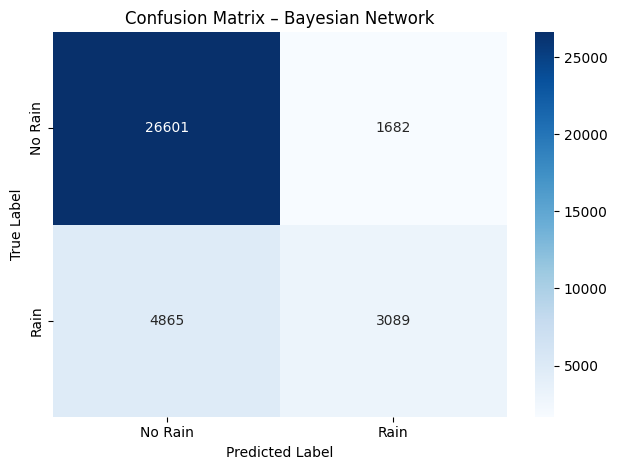

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 10: Evaluate model accuracy
accuracy = accuracy_score(y, y_pred_bn)
print("Bayesian Network Accuracy:", accuracy)

# Step 11: Generate and visualize confusion matrix
cm = confusion_matrix(y, y_pred_bn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Bayesian Network')
plt.tight_layout()
plt.show()
